# Lab 1 | Gradient descent
> Author: Serafym Podolyanchuk

In [70]:
import numpy as np
import time
import matplotlib.pyplot as plt

## Part 1

In [71]:
# Starting point
x_0 = np.array([-2, 2])

# Constants
ITER_LIMIT = 10_000
STOPPING_CRITERIA = 0.0001 # 10 ^ (-4)
G = [0.1, 0.01, 0.001] # gamma

/tmp/ipykernel_481/3446289849.py:2: RuntimeWarning: overflow encountered in scalar power
  return 100 * (x[1] - x[0]**2)**2 + (1 - x[0])**2
/tmp/ipykernel_481/3446289849.py:6: RuntimeWarning: overflow encountered in scalar power
  df_dx1 = -400 * x1 * (x2 - x1**2) - 2 * (1 - x1)
/tmp/ipykernel_481/3446289849.py:7: RuntimeWarning: overflow encountered in scalar power
  df_dx2 = 200 * (x2 - x1**2)
/tmp/ipykernel_481/3446289849.py:6: RuntimeWarning: overflow encountered in scalar multiply
  df_dx1 = -400 * x1 * (x2 - x1**2) - 2 * (1 - x1)


Diverged with gamma=0.1 at iteration 6
X (k) = [nan nan] after 6 iterations which took 0.0007154570012062322 time
Diverged with gamma=0.01 at iteration 6
X (k) = [nan nan] after 6 iterations which took 0.00036258899854146875 time
X (k) = [0.99117313 0.98238866] after 10000 iterations which took 0.17104523099988 time


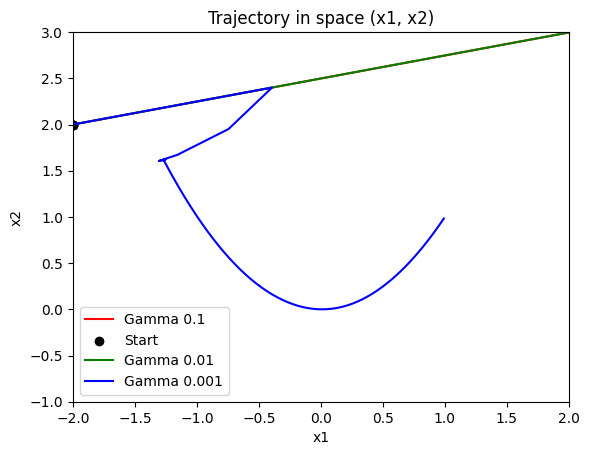

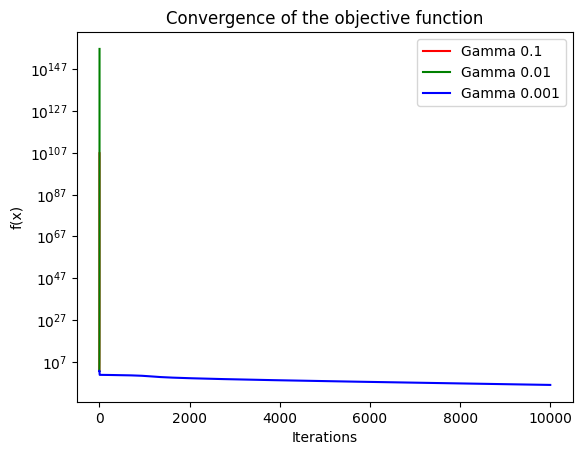

In [72]:
def calculate_objective(x):
    return 100 * (x[1] - x[0]**2)**2 + (1 - x[0])**2

def compute_gradient(x):
    x1, x2 = x[0], x[1]
    df_dx1 = -400 * x1 * (x2 - x1**2) - 2 * (1 - x1)
    df_dx2 = 200 * (x2 - x1**2)
    return np.array([df_dx1, df_dx2])

def gradient_descent(x_0, iter_limit, stopping_criteria, gamma):
  x_k = np.array(x_0, dtype=float)

  history = []
  objective_history = []

  start_time = time.perf_counter()

  iter_count = 0
  while iter_count < iter_limit:
    grad = compute_gradient(x_k)
    history.append(x_k)
    objective_history.append(calculate_objective(x_k))

    if np.linalg.norm(grad) < stopping_criteria:
      break

    x_k = x_k - gamma * grad

    iter_count += 1

    if not np.isfinite(x_k).all():
      print(f"Diverged with gamma={gamma} at iteration {iter_count}")
      return np.array([np.nan, np.nan]), iter_count, time.perf_counter() - start_time, history, objective_history

  duration = time.perf_counter() - start_time

  return x_k, iter_count, duration, history, objective_history

fig1, ax1 = plt.subplots()
fig2, ax2 = plt.subplots()

for g,c in zip(G, ["red", "green","blue"]):
  x_k, iter_count, duration, history, objective_history = gradient_descent(x_0, ITER_LIMIT, STOPPING_CRITERIA, g)
  print(f"X (k) = {x_k} after {iter_count} iterations which took {duration} time")

  history = np.array(history)
  objective_history = np.array(objective_history)

  if np.isfinite(history).all() and len(history) > 0:
      ax1.plot(history[:, 0], history[:, 1], label=f"Gamma {g}", color=c)
      ax1.scatter(history[0,0], history[0,1], color='black', label="Start" if g==G[0] else "")

      ax2.plot(range(len(objective_history)), objective_history, label=f"Gamma {g}", color=c)

ax1.set_title("Trajectory in space (x1, x2)")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
ax1.set_xlim(-2, 2)
ax1.set_ylim(-1, 3)
ax1.legend()

ax2.set_title("Convergence of the objective function")
ax2.set_xlabel("Iterations")
ax2.set_ylabel("f(x)")
ax2.set_yscale('log')
ax2.legend()

plt.show()

X (k) = [0.99988822 0.999776  ] after 20903 iterations which took 0.2646759219969681 time
X (k) = [0.99988821 0.99977598] after 2125468 iterations which took 26.986087044999294 time
X (k) = [-0.76180113  0.58842339] after 10000000 iterations which took 132.26109183200242 time


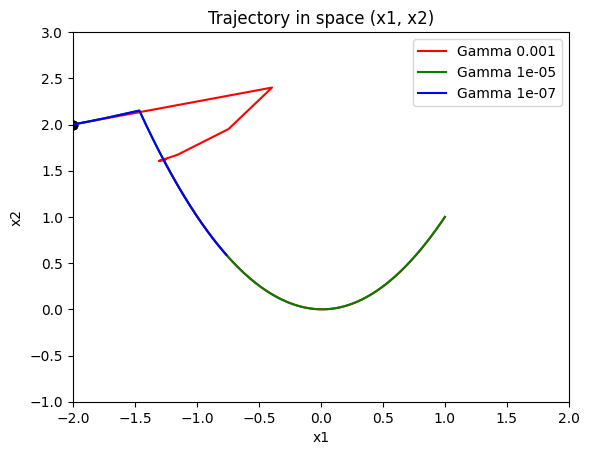

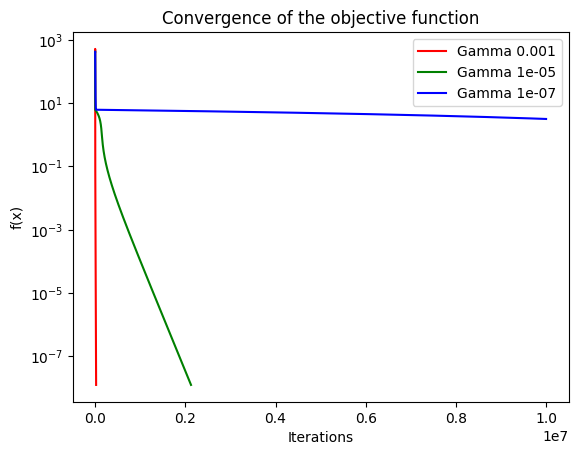

In [73]:
lowest_g = [0.001, 0.00001, 0.0000001]

fig1, ax1 = plt.subplots()
fig2, ax2 = plt.subplots()

for g,c in zip(lowest_g, ["red", "green","blue"]):
  x_k, iter_count, duration, history, objective_history = gradient_descent(x_0, 10_000_000, STOPPING_CRITERIA, g)
  print(f"X (k) = {x_k} after {iter_count} iterations which took {duration} time")

  history = np.array(history)
  objective_history = np.array(objective_history)

  if np.isfinite(history).all() and len(history) > 0:
      ax1.plot(history[:, 0], history[:, 1], label=f"Gamma {g}", color=c)
      ax1.scatter(history[0,0], history[0,1], color='black', label="Start" if g==G[0] else "")

      ax2.plot(range(len(objective_history)), objective_history, label=f"Gamma {g}", color=c)

ax1.set_title("Trajectory in space (x1, x2)")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
ax1.set_xlim(-2, 2)
ax1.set_ylim(-1, 3)
ax1.legend()

ax2.set_title("Convergence of the objective function")
ax2.set_xlabel("Iterations")
ax2.set_ylabel("f(x)")
ax2.set_yscale('log')
ax2.legend()

plt.show()

In [74]:
m, n = 100, 10
A = np.random.randn(m, n)
b = np.random.randn(m)
x_0 = np.zeros(n)
ITER_LIMIT = 50

In [75]:
def calculate_objective(x, A, b):
    m = len(b)
    error = A @ x - b
    return (1 / (2 * m)) * np.linalg.norm(error)**2

def compute_gradient(x, A, b):
    m = len(b)
    return (1 / m) * A.T @ (A @ x - b)

def gradient_descent(x_0, A, b, iter_limit, gamma):
    x_k = np.array(x_0, dtype=float)
    obj_history = []
    start_time = time.perf_counter()

    for i in range(iter_limit):
        obj_history.append(calculate_objective(x_k, A, b))
        grad = compute_gradient(x_k, A, b)
        x_k = x_k - gamma * grad

    duration = time.perf_counter() - start_time
    return x_k, duration, obj_history

gamma=0.1: Final Obj = 0.419998, Time = 0.000916s
gamma=1/beta: Final Obj = 0.419990, Time = 0.002066s
gamma=1/L: Final Obj = 0.422337, Time = 0.001977s


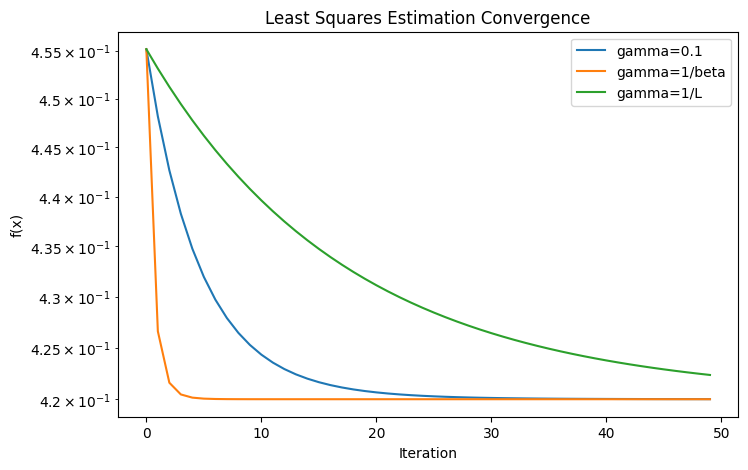

In [76]:
beta = (1/m) * (np.linalg.norm(A, 2)**2)
L = (1/m) * (np.linalg.norm(A.T @ A, 2) * 20 + np.linalg.norm(A.T @ b, 2))

gammas_2 = [0.1, 1/beta, 1/L]
labels_2 = ["gamma=0.1", "gamma=1/beta", "gamma=1/L"]

fig, ax = plt.subplots(figsize=(8, 5))

for g, lbl in zip(gammas_2, labels_2):
    res, dur, hist = gradient_descent(x_0, A, b, ITER_LIMIT, g)
    print(f"{lbl}: Final Obj = {hist[-1]:.6f}, Time = {dur:.6f}s")
    ax.plot(range(len(hist)), hist, label=lbl)

ax.set_title("Least Squares Estimation Convergence")
ax.set_xlabel("Iteration")
ax.set_ylabel("f(x)")
ax.set_yscale('log')
ax.legend()
plt.show()

In [77]:
def g1(x): return 0.5 * (x - np.log(1 + x))**2
def dg1(x): return (x - np.log(1 + x)) * (1 - 1/(1 + x))

def g2(x): return 0.5 * (x - np.log(2 + x))**2
def dg2(x): return (x - np.log(2 + x)) * (1 - 1/(2 + x))

L1 = 1.0
L2 = 1.0
ITER_LIMIT = 100

def gradient_descent(x_0, g_func, dg_func, iter_limit, gamma):
    x_k = float(x_0)
    obj_history = []
    x_values = []
    start_time = time.perf_counter()

    for i in range(iter_limit):
        if i % 10 == 0:
            x_values.append((i, x_k, g_func(x_k)))
        obj_history.append(g_func(x_k))
        x_k = x_k - gamma * dg_func(x_k)

    duration = time.perf_counter() - start_time
    return x_k, duration, obj_history, x_values


Results for g1 (ln(1+x)):
Iter 0: x=2.0000, g(x)=4.0625e-01
Iter 10: x=0.4618, g(x)=3.3727e-03
Iter 20: x=0.3025, g(x)=7.3001e-04
Iter 30: x=0.2365, g(x)=2.9298e-04
Iter 40: x=0.1990, g(x)=1.5328e-04
Iter 50: x=0.1743, g(x)=9.2893e-05
Iter 60: x=0.1566, g(x)=6.1803e-05
Iter 70: x=0.1432, g(x)=4.3852e-05
Iter 80: x=0.1325, g(x)=3.2614e-05
Iter 90: x=0.1239, g(x)=2.5140e-05

Results for g2 (ln(2+x)):
Iter 0: x=2.0000, g(x)=1.8832e-01
Iter 10: x=1.1474, g(x)=3.4063e-07
Iter 20: x=1.1462, g(x)=1.2399e-12
Iter 30: x=1.1462, g(x)=4.5186e-18
Iter 40: x=1.1462, g(x)=1.6468e-23
Iter 50: x=1.1462, g(x)=6.1630e-29
Iter 60: x=1.1462, g(x)=0.0000e+00
Iter 70: x=1.1462, g(x)=0.0000e+00
Iter 80: x=1.1462, g(x)=0.0000e+00
Iter 90: x=1.1462, g(x)=0.0000e+00


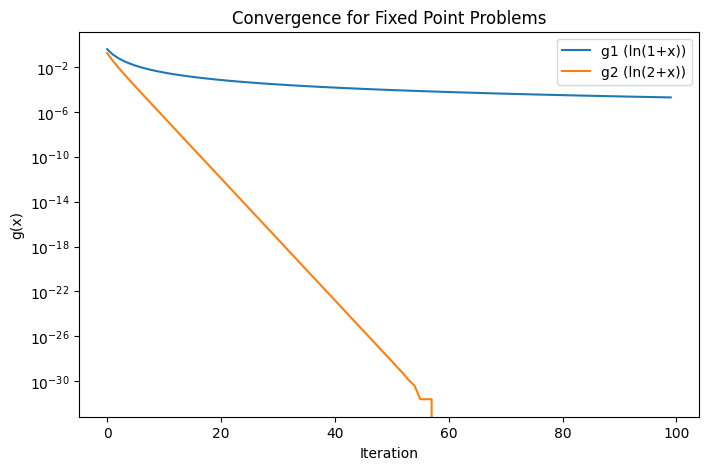

In [78]:
x_k1, dur1, hist1, vals1 = gradient_descent(2.0, g1, dg1, ITER_LIMIT, 1/L1)
print("\nResults for g1 (ln(1+x)):")
for i, x, val in vals1: print(f"Iter {i}: x={x:.4f}, g(x)={val:.4e}")

x_k2, dur2, hist2, vals2 = gradient_descent(2.0, g2, dg2, ITER_LIMIT, 1/L2)
print("\nResults for g2 (ln(2+x)):")
for i, x, val in vals2: print(f"Iter {i}: x={x:.4f}, g(x)={val:.4e}")

plt.figure(figsize=(8, 5))
plt.plot(hist1, label="g1 (ln(1+x))")
plt.plot(hist2, label="g2 (ln(2+x))")
plt.title("Convergence for Fixed Point Problems")
plt.xlabel("Iteration")
plt.ylabel("g(x)")
plt.yscale('log')
plt.legend()
plt.show()